# Analysis 1 — Customer Segmentation (RFMTC)

**Business question.** Which customer groups carry the most profit potential, so the business can concentrate retention and growth spend where it pays back?

**Approach (business leads, tech serves).** Segment on **RFMTC** — Recency, Frequency, Monetary, **T**ime (tenure) and **C**hurn-probability (1−P(alive) from a BG/NBD model) — then K-Means, choosing *k* where the elbow, silhouette *and* business interpretability agree.

> Implementation lives in [`src/segmentation/run_segmentation.py`](../src/segmentation/run_segmentation.py); this notebook narrates and runs it.

## Step 1 — Build the RFMTC features and fit K-Means
Features are skew-corrected (log) and standardised; we scan k=2..10 and pick the best silhouette in a business-actionable window.

In [1]:
from src.segmentation.run_segmentation import main
main()

Selected k=6 (best silhouette within business window (6, 8))

=== SEGMENT PROFILE (top of table) ===
High-value, active            1013   avg £11,791  churn 0.02  70.0% revenue
Mid-value, active, at-risk    1545   avg £1,701   churn 0.05  15.4% revenue
High-value, lapsing, at-risk   250   avg £2,884   churn 0.74   4.2% revenue
k=6 | members=5852


## Step 2 — Where the revenue sits, and the value map
17% of members (High-value, active) drive **70% of revenue**. The value map exposes the rescue target: high spend, gone stale, high churn.

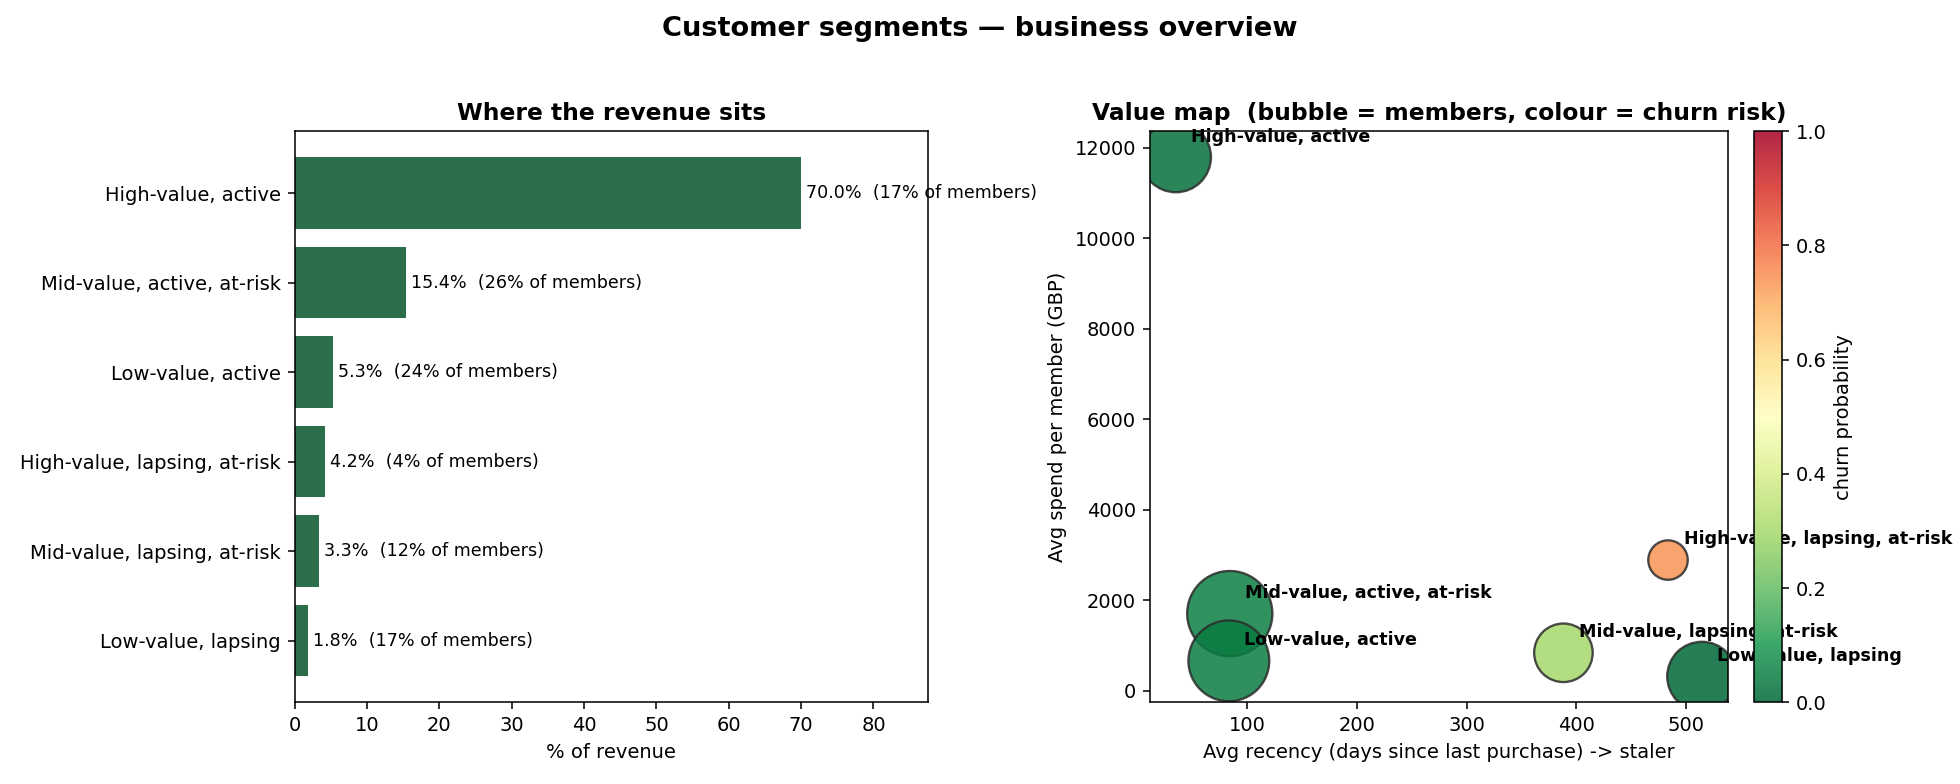

In [2]:
from IPython.display import Image
Image("../reports/figures/seg_business_overview.png")

## Step 3 — How the clusters separate (PCA, 78% variance)

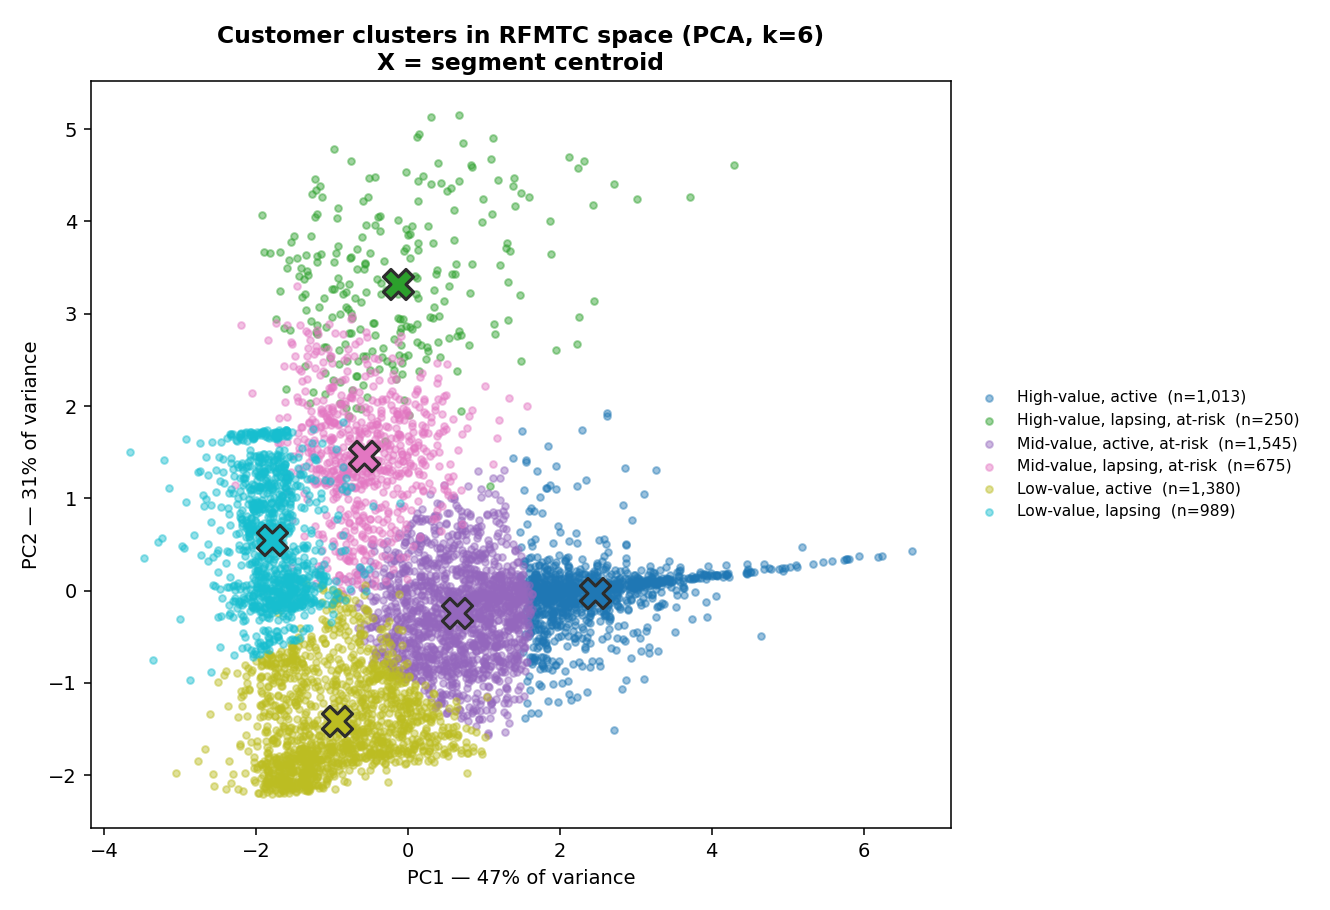

In [3]:
Image("../reports/figures/seg_cluster_scatter.png")

## Step 4 — Choosing k (elbow + silhouette)

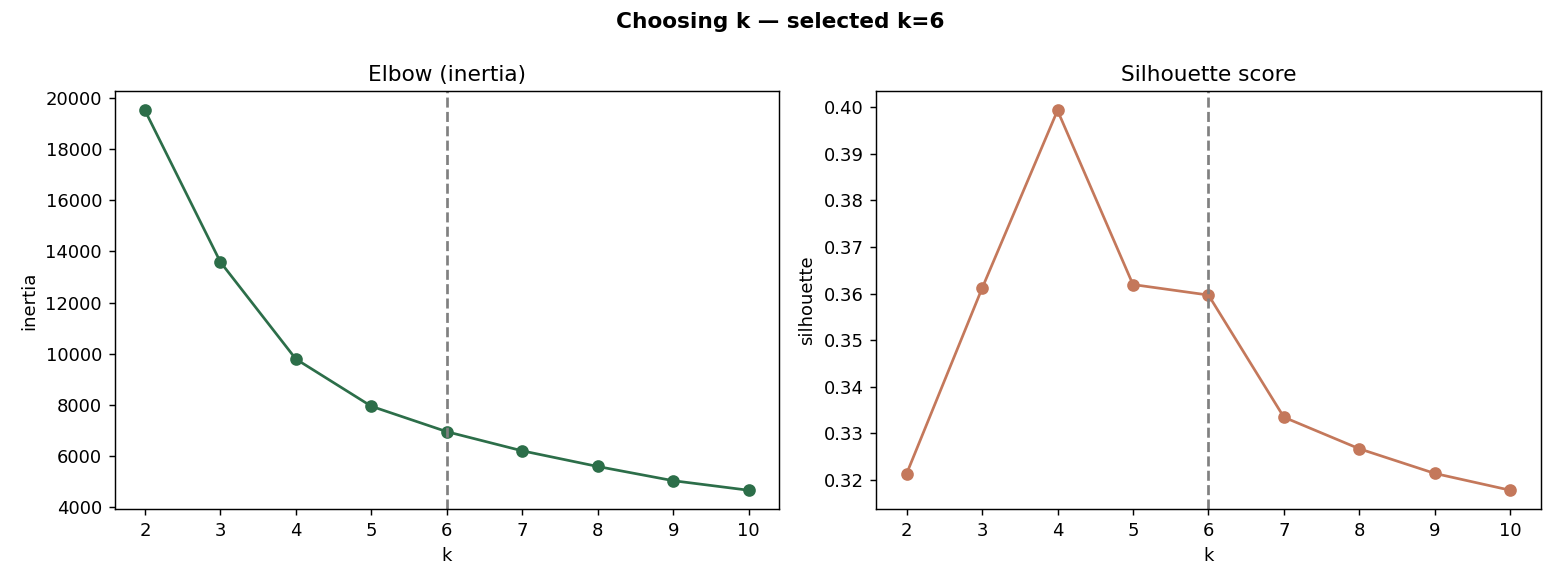

In [4]:
Image("../reports/figures/seg_elbow_silhouette.png")

## Takeaway
Six actionable segments. We prioritise three by *strategic job*: **Protect** (High-value, active — 70% of revenue), **Rescue** (High-value, lapsing, at-risk — ~£0.7M at risk), and **Grow** (Mid-value, active — the CLV growth engine). See `README.md` for the action plans.